## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

## Loading Data

In [2]:
DATA_PATH = Path("../data/raw")

In [4]:
train_df = pd.read_csv(DATA_PATH / "train.csv")

test_df = pd.read_csv(DATA_PATH / "test.csv")

stores_df = pd.read_csv(DATA_PATH / "stores.csv")

holidays_df = pd.read_csv(DATA_PATH / "holidays_events.csv")

oil_df = pd.read_csv(DATA_PATH / "oil.csv")

transactions_df = pd.read_csv(DATA_PATH / "transactions.csv")

##

## Verify Loading

In [ ]:
datasets = {
    "Train": train_df,
    "Test": test_df,
    "Stores": stores_df,
    "Holidays": holidays_df,
    "Oil": oil_df,
    "Transactions": transactions_df
}

for name, df in datasets.items():
    print(f"{name:<15} {df.shape}") #:< for space between nae and df

Train           (3000888, 6)
Test            (28512, 5)
Stores          (54, 5)
Holidays        (350, 6)
Oil             (1218, 2)
Transactions    (83488, 3)


In [6]:
for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    display(df.head())

Train


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


Test


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


Stores


...

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


Oil


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Transactions


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


## DataSet Summary

In [7]:
def dataset_summary(df, name):
    """
    Display a high-level summary of a dataset.
    """
    
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Rows               : {df.shape[0]:,}")
    print(f"Columns            : {df.shape[1]}")
    print(f"Memory Usage (MB)  : {df.memory_usage(deep=True).sum() / 1024**2:.2f}")

In [8]:
for name, df in datasets.items():
    dataset_summary(df, name)

Train
Rows               : 3,000,888
Columns            : 6
Memory Usage (MB)  : 431.45
Test
Rows               : 28,512
Columns            : 5
Memory Usage (MB)  : 3.88
Stores
Rows               : 54
Columns            : 5
Memory Usage (MB)  : 0.01
Holidays
Rows               : 350
Columns            : 6
Memory Usage (MB)  : 0.10
Oil
Rows               : 1,218
Columns            : 2
Memory Usage (MB)  : 0.08
Transactions
Rows               : 83,488
Columns            : 3
Memory Usage (MB)  : 5.97


## Column Information

In [9]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(
        pd.DataFrame({
            "Column": df.columns,
            "Data Type": df.dtypes.astype(str)
        })
    )

Train


,Column,Data Type
id,id,int64
date,date,object
store_nbr,store_nbr,int64
family,family,object
sales,sales,float64
onpromotion,onpromotion,int64


Test


,Column,Data Type
id,id,int64
date,date,object
store_nbr,store_nbr,int64
family,family,object
onpromotion,onpromotion,int64


Stores


...

,Column,Data Type
date,date,object
type,type,object
locale,locale,object
locale_name,locale_name,object
description,description,object
transferred,transferred,bool


Oil


,Column,Data Type
date,date,object
dcoilwtico,dcoilwtico,float64


Transactions


,Column,Data Type
date,date,object
store_nbr,store_nbr,int64
transactions,transactions,int64


## Data Types Distribution

In [12]:
for name, df in datasets.items():
    print(f"\n{name}")

    display(
        df.dtypes.value_counts()
    )


Train


int64      3
object     2
float64    1
Name: count, dtype: int64


Test


int64     3
object    2
Name: count, dtype: int64


Stores


...

object    5
bool      1
Name: count, dtype: int64


Oil


object     1
float64    1
Name: count, dtype: int64


Transactions


int64     2
object    1
Name: count, dtype: int64

In [18]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3000888.00,1500443.50,866281.89,0.00,750221.75,1500443.50,2250665.25,3000887.00
store_nbr,3000888.00,27.50,15.59,1.00,14.00,27.50,41.00,54.00
sales,3000888.00,357.78,1102.00,0.00,0.00,11.00,195.85,124717.00
onpromotion,3000888.00,2.60,12.22,0.00,0.00,0.00,0.00,741.00


In [19]:
train_df.describe(include="object").T

,count,unique,top,freq
date,3000888,1684,2017-08-15,1782
family,3000888,33,AUTOMOTIVE,90936


In [20]:
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [25]:
train_df["date"] = pd.to_datetime(train_df["date"])

In [26]:
train_df["date"].head()

0   2013-01-01
1   2013-01-01
2   2013-01-01
3   2013-01-01
4   2013-01-01
Name: date, dtype: datetime64[ns]

In [27]:
print("Start Date:",  train_df["date"].min())
print("End Date:", train_df["date"].max())

Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [28]:
duration = (
    train_df["date"].max() -
    train_df["date"].min()
)

print(duration)

1687 days 00:00:00


In [29]:
train_df["sales"].describe()

count   3000888.00
mean        357.78
std        1102.00
min           0.00
25%           0.00
50%          11.00
75%         195.85
max      124717.00
Name: sales, dtype: float64

In [30]:
(train_df["sales"] < 0).sum()

np.int64(0)

In [31]:
for column in train_df.columns:

    print(
        f"{column:<20}",
        train_df[column].nunique()
    )

id                   3000888
date                 1684
store_nbr            54
family               33
sales                379610
onpromotion          362


## Missing values

In [32]:
def missing_values(df, dataset_name):

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    missing_df = pd.DataFrame({
        "Missing Values": missing,
        "Percentage": (missing / len(df)) * 100
    })

    missing_df["Percentage"] = (
        missing_df["Percentage"]
        .round(2)
    )

    print(f"\n{dataset_name}")

    if missing_df.empty:
        print("No Missing Values")

    else:
        display(
            missing_df.sort_values(
                by="Percentage",
                ascending=False
            )
        )

In [33]:
for name, df in datasets.items():
    missing_values(df, name)


Train
No Missing Values

Test
No Missing Values

Stores
No Missing Values

Holidays
No Missing Values

Oil


,Missing Values,Percentage
dcoilwtico,43,3.53



Transactions
No Missing Values


In [34]:
oil_df.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


## Duplicate Values

In [35]:
def duplicate_records(df, dataset_name):

    duplicates = df.duplicated().sum()

    print(f"{dataset_name}")
    print(f"Duplicate Rows : {duplicates:,}")

In [36]:
for name, df in datasets.items():
    duplicate_records(df, name)

Train
Duplicate Rows : 0
Test
Duplicate Rows : 0
Stores
Duplicate Rows : 0
Holidays
Duplicate Rows : 0
Oil
Duplicate Rows : 0
Transactions
Duplicate Rows : 0


## Data Types

In [43]:
for name, df in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    display(df.dtypes)

Train


id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Test


id              int64
date           object
store_nbr       int64
family         object
onpromotion     int64
dtype: object

Stores


...

date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

Oil


date           object
dcoilwtico    float64
dtype: object

Transactions


date            object
store_nbr        int64
transactions     int64
dtype: object

## Check Identifier Quality

In [44]:
identifier_columns = [
    "store_nbr",
    "family"
]

for column in identifier_columns:

    print("=" * 50)
    print(column)
    print("=" * 50)

    print(train_df[column].nunique())

    print()

    display(train_df[column].value_counts().head())

store_nbr
54



store_nbr
1     55572
10    55572
11    55572
12    55572
13    55572
Name: count, dtype: int64

family
33



family
AUTOMOTIVE    90936
BABY CARE     90936
BEAUTY        90936
BEVERAGES     90936
BOOKS         90936
Name: count, dtype: int64

## EDA

In [45]:
train_df["sales"].describe()

count   3000888.00
mean        357.78
std        1102.00
min           0.00
25%           0.00
50%          11.00
75%         195.85
max      124717.00
Name: sales, dtype: float64

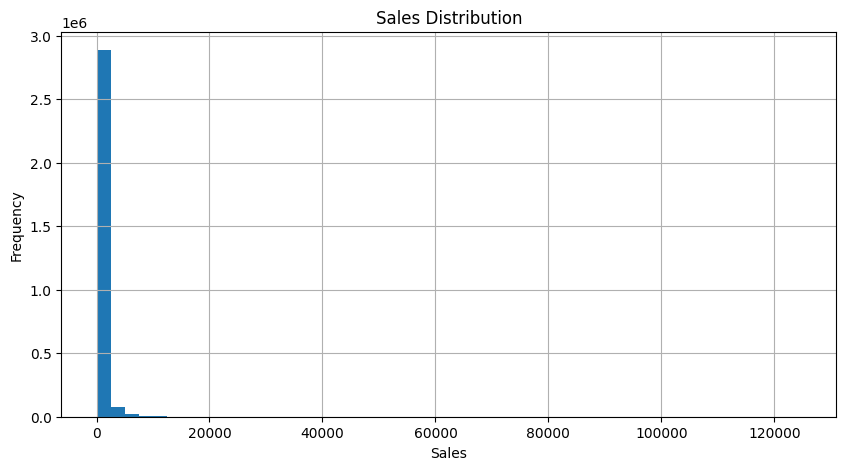

In [46]:
plt.figure(figsize=(10,5))

train_df["sales"].hist(bins=50)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

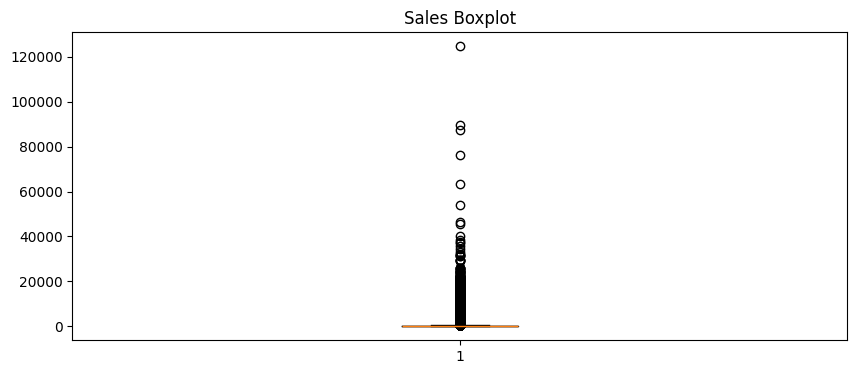

In [47]:
plt.figure(figsize=(10,4))

plt.boxplot(train_df["sales"])

plt.title("Sales Boxplot")

plt.show()

In [48]:
daily_sales = (
    train_df
    .groupby("date")["sales"]
    .sum()
)

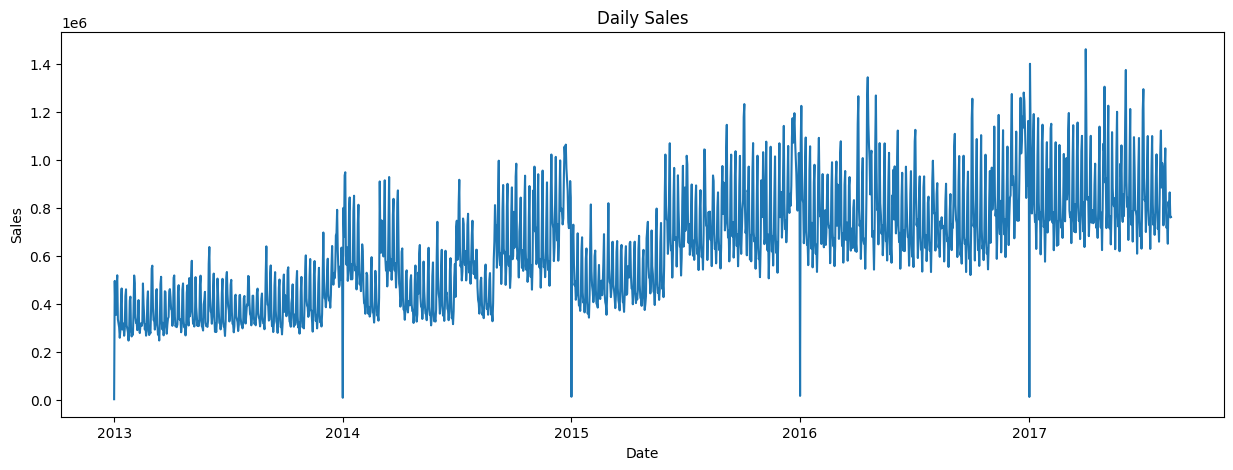

In [49]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [50]:
train_df["year"] = train_df["date"].dt.year
train_df["month"] = train_df["date"].dt.month

In [51]:
monthly_sales = (
    train_df
    .groupby(
        ["year","month"]
    )["sales"]
    .sum()
    .reset_index()
)

In [52]:
monthly_sales.head()

,year,month,sales
0,2013,1,10327624.74
1,2013,2,9658959.78
2,2013,3,11428497.04
3,2013,4,10993464.74
4,2013,5,11597704.01


## Aggregate Sales by Product Family

In [53]:
family_sales = (
    train_df
    .groupby("family", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
)

family_sales.head(10)

,family,sales
12,GROCERY I,343462734.89
3,BEVERAGES,216954486.00
30,PRODUCE,122704684.68
7,CLEANING,97521289.00
8,DAIRY,64487709.00
5,BREAD/BAKERY,42133945.58
28,POULTRY,31876004.47
24,MEATS,31086468.40
25,PERSONAL CARE,24592051.00
9,DELI,24110322.47


## Visualize Top 10 Families

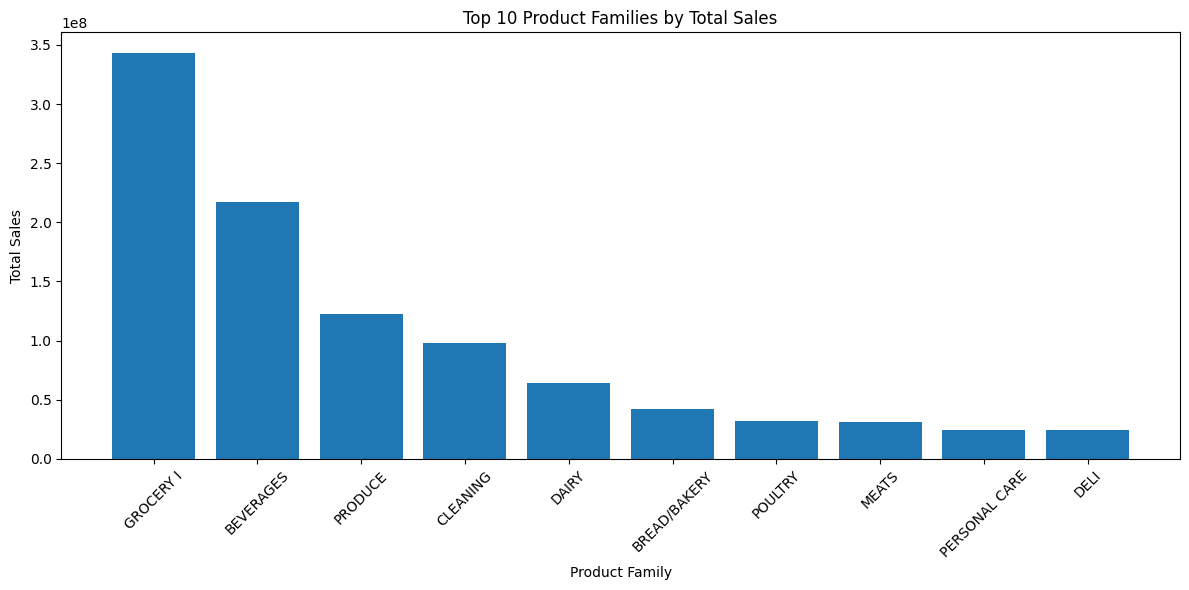

In [54]:
top_10_family = family_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_family["family"],
    top_10_family["sales"]
)

plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Lowest Selling Families

In [55]:
family_sales.tail(10)

,family,sales
0,AUTOMOTIVE,554822.00
20,LAWN AND GARDEN,548842.00
26,PET SUPPLIES,356584.00
2,BEAUTY,337893.00
31,SCHOOL AND OFFICE SUPPLIES,269316.00
23,MAGAZINES,266359.00
14,HARDWARE,103470.00
17,HOME APPLIANCES,41601.00
1,BABY CARE,10051.00
4,BOOKS,6438.00


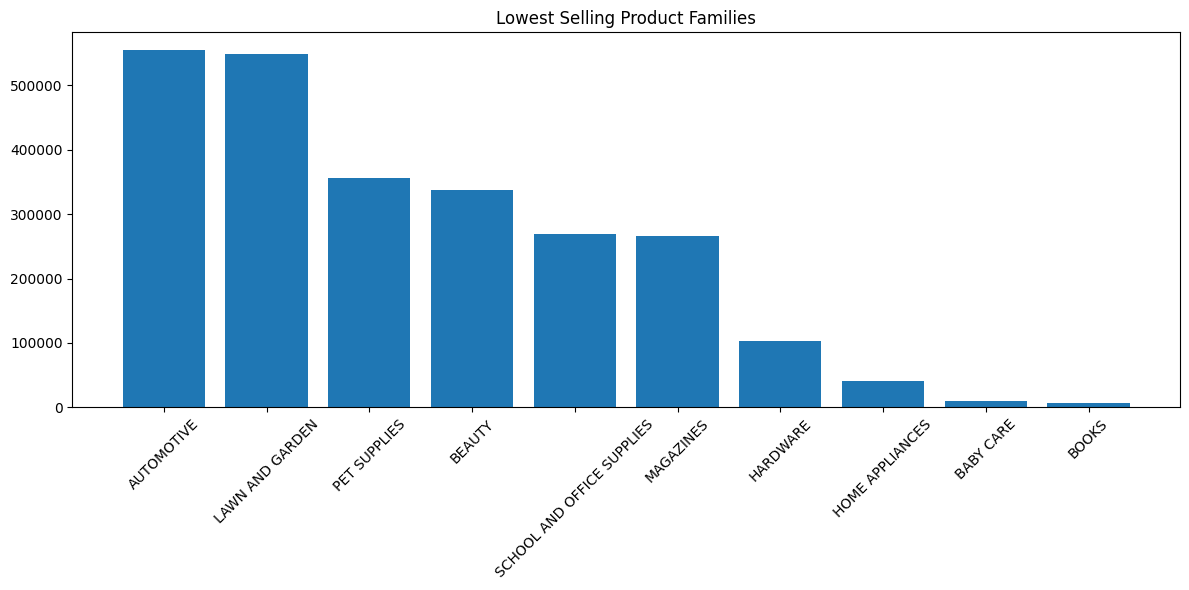

In [56]:
bottom_10_family = family_sales.tail(10)

plt.figure(figsize=(12,6))

plt.bar(
    bottom_10_family["family"],
    bottom_10_family["sales"]
)

plt.title("Lowest Selling Product Families")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## STores Aggregate

In [57]:
store_sales = (
    train_df
    .groupby("store_nbr", as_index=False)["sales"]
    .sum()
    .sort_values(by="sales", ascending=False)
)

store_sales.head()

,store_nbr,sales
43,44,62087553.25
44,45,54498010.42
46,47,50948310.06
2,3,50481910.19
48,49,43420095.78


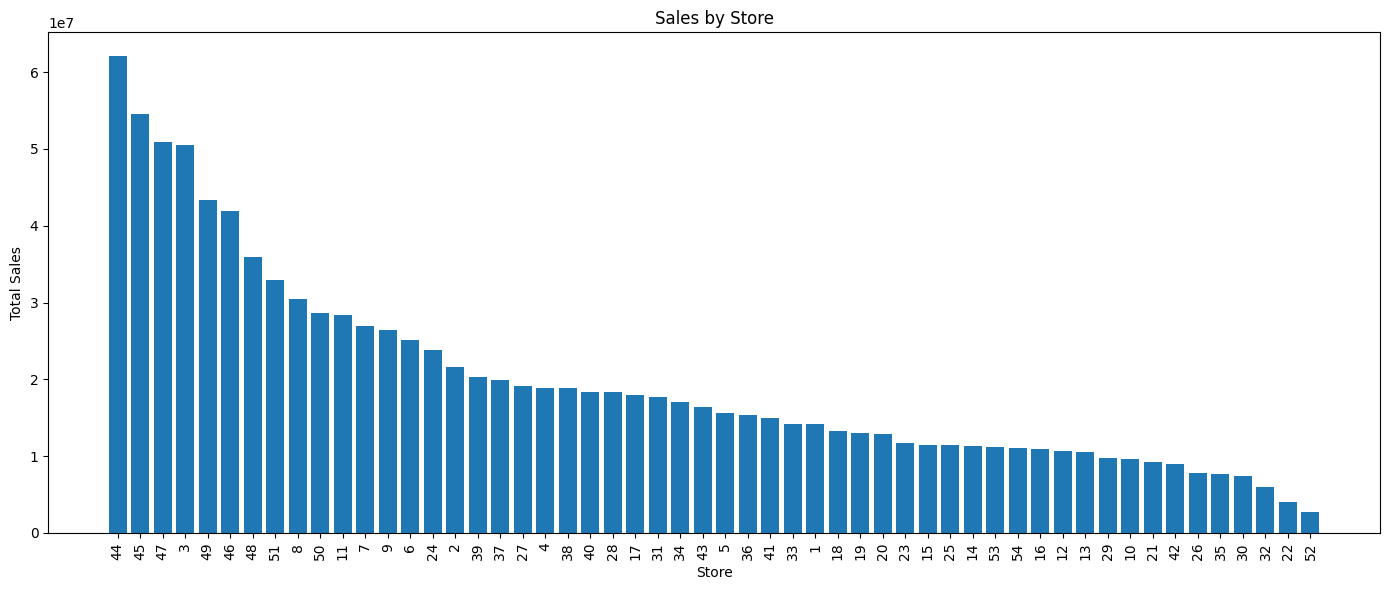

In [58]:
plt.figure(figsize=(14,6))

plt.bar(
    store_sales["store_nbr"].astype(str),
    store_sales["sales"]
)

plt.title("Sales by Store")

plt.xlabel("Store")

plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

## Sales by Store Type

In [59]:
store_analysis = train_df.merge(
    stores_df,
    on="store_nbr",
    how="left"
)

In [60]:
type_sales = (
    store_analysis
    .groupby("type", as_index=False)["sales"]
    .sum()
)

type_sales

,type,sales
0,A,353043841.80
1,B,145260635.13
2,C,164434742.56
3,D,351083296.86
4,E,59822435.84


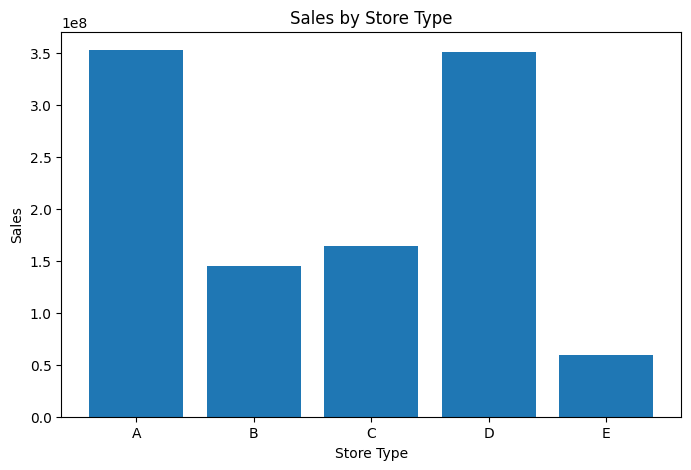

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    type_sales["type"],
    type_sales["sales"]
)

plt.title("Sales by Store Type")

plt.xlabel("Store Type")

plt.ylabel("Sales")

plt.show()